In [1]:
import pathlib

import matplotlib.pyplot as plt
import pandas as pd
from pycytominer import normalize
from pycytominer.cyto_utils import output

In [2]:
# set  path
normalized_data_path = pathlib.Path(
    "../data/CP_scDINO_features/combined_CP_scDINO_norm.parquet"
).resolve()

endpoint_data_path = pathlib.Path(
    "../../6.process_CP_features/data/4.normalized_data/endpoints/normalized_profile.parquet"
).resolve()

endpoint_none_filtered_data_path_for_copy = pathlib.Path(
    "../data/CP_scDINO_features/endpoint_CP_norm.parquet"
).resolve()

# outputs
filtered_normalized_path = pathlib.Path(
    "../data/CP_scDINO_features/combined_CP_scDINO_norm_filtered_tracks.parquet"
).resolve()
filtered_endpoint_path = pathlib.Path(
    "../data/CP_scDINO_features/endpoint_CP_norm_filtered_tracks.parquet"
).resolve()


# load data
combined_df = pd.read_parquet(normalized_data_path)
endpoint_df = pd.read_parquet(endpoint_data_path)
endpoint_df.to_parquet(endpoint_none_filtered_data_path_for_copy)
combined_df.head()

,Metadata_plate,Metadata_Well,Metadata_number_of_singlecells,Metadata_compound,Metadata_dose,Metadata_control,Metadata_ImageNumber,Metadata_FOV,Metadata_Time,Metadata_Cells_Number_Object_Number,...,channel_DNA_cls_feature_91_scDINO,channel_DNA_cls_feature_92_scDINO,channel_DNA_cls_feature_93_scDINO,channel_DNA_cls_feature_94_scDINO,channel_DNA_cls_feature_95_scDINO,channel_DNA_cls_feature_96_scDINO,channel_DNA_cls_feature_97_scDINO,channel_DNA_cls_feature_98_scDINO,channel_DNA_cls_feature_99_scDINO,channel_DNA_cls_feature_9_scDINO
0,1,C-10,156,Staurosporine,78.13,test,1,0003,0.0,6,...,-0.421030,-0.639528,-1.108697,0.508837,-1.180882,0.521719,0.419948,-0.254621,0.140152,-0.311706
1,1,C-10,156,Staurosporine,78.13,test,1,0003,0.0,7,...,-1.118932,-1.264854,0.263361,-0.473379,-1.034858,-0.412041,0.470434,0.819060,0.522236,-2.358482
2,1,C-10,156,Staurosporine,78.13,test,1,0003,0.0,10,...,-0.413004,0.982228,1.487644,0.183418,-0.464693,-0.696133,1.038610,0.218406,-0.063818,-1.270270
3,1,C-10,156,Staurosporine,78.13,test,1,0003,0.0,11,...,-1.030118,-1.324591,-0.858296,1.053740,-1.105719,-0.494646,-0.851002,0.691902,0.559527,0.201144
4,1,C-10,156,Staurosporine,78.13,test,1,0003,0.0,12,...,-0.049551,1.391577,0.721089,-0.230744,2.137543,-0.730854,0.003878,-1.447163,1.791341,-0.927917


In [3]:
endpoint_df.head()

,Metadata_plate,Metadata_Well,Metadata_number_of_singlecells,Metadata_compound,Metadata_dose,Metadata_control,Metadata_ImageNumber,Metadata_FOV,Metadata_Time,Metadata_Cells_Number_Object_Number,...,Nuclei_Texture_SumVariance_DNA_3_02_256,Nuclei_Texture_SumVariance_DNA_3_03_256,Nuclei_Texture_Variance_AnnexinV_3_00_256,Nuclei_Texture_Variance_AnnexinV_3_01_256,Nuclei_Texture_Variance_AnnexinV_3_02_256,Nuclei_Texture_Variance_AnnexinV_3_03_256,Nuclei_Texture_Variance_DNA_3_00_256,Nuclei_Texture_Variance_DNA_3_01_256,Nuclei_Texture_Variance_DNA_3_02_256,Nuclei_Texture_Variance_DNA_3_03_256
0,1,C-10,173,Staurosporine,78.13,test,1,0003,13.0,2.0,...,1.164816,1.109369,-0.155641,-0.169559,-0.160398,-0.152111,1.378142,1.329342,1.364077,1.368531
1,1,C-10,173,Staurosporine,78.13,test,1,0003,13.0,12.0,...,1.183497,1.111247,-0.284004,-0.275537,-0.285401,-0.279603,1.413288,1.363242,1.431518,1.491964
2,1,C-10,173,Staurosporine,78.13,test,1,0003,13.0,14.0,...,0.019218,0.014923,-0.306032,-0.303497,-0.305839,-0.295858,0.069212,0.072790,0.076769,0.070535
3,1,C-10,173,Staurosporine,78.13,test,1,0003,13.0,19.0,...,0.873459,0.826243,-0.264638,-0.256248,-0.256708,-0.251117,1.041571,1.017510,1.054862,1.040392
4,1,C-10,173,Staurosporine,78.13,test,1,0003,13.0,23.0,...,2.870420,2.464527,0.112208,0.108085,0.149727,0.096069,3.296162,3.231387,3.373477,3.345125


In [4]:
shared_track_ids = {
    "Metadata_Well": [],
    "Metadata_FOV": [],
    "Metadata_track_id": [],
}
tracks_stats = {
    "Metadata_Well": [],
    "Metadata_FOV": [],
    "number_of_tracks_in_timelapse_data": [],
    "number_of_tracks_in_endpoint_data": [],
    "number_of_common_tracks": [],
    "number_of_lost_tracks": [],
}
for well in combined_df["Metadata_Well"].unique():
    tmp_combined_df = combined_df[combined_df["Metadata_Well"] == well]
    tmp_endpoint_df = endpoint_df[endpoint_df["Metadata_Well"] == well]
    for fov in tmp_combined_df["Metadata_FOV"].unique():
        tmp_combined_df_fov = tmp_combined_df[tmp_combined_df["Metadata_FOV"] == fov]
        tmp_endpoint_df_fov = tmp_endpoint_df[tmp_endpoint_df["Metadata_FOV"] == fov]
        timelapse_track_ids = set(tmp_combined_df_fov["Metadata_track_id"].unique())
        endpoint_track_ids = set(tmp_endpoint_df_fov["Metadata_track_id"].unique())
        common_track_ids = timelapse_track_ids.intersection(endpoint_track_ids)

        shared_track_ids["Metadata_Well"].extend([well] * len(common_track_ids))
        shared_track_ids["Metadata_FOV"].extend([fov] * len(common_track_ids))
        shared_track_ids["Metadata_track_id"].extend(common_track_ids)

        tracks_stats["Metadata_Well"].append(well)
        tracks_stats["Metadata_FOV"].append(fov)
        tracks_stats["number_of_tracks_in_timelapse_data"].append(
            len(timelapse_track_ids)
        )
        tracks_stats["number_of_tracks_in_endpoint_data"].append(
            len(endpoint_track_ids)
        )
        tracks_stats["number_of_common_tracks"].append(len(common_track_ids))
        tracks_stats["number_of_lost_tracks"].append(
            len(timelapse_track_ids) - len(common_track_ids)
        )

tracks_stats_df = pd.DataFrame(tracks_stats)
shared_track_ids_df = pd.DataFrame(shared_track_ids)

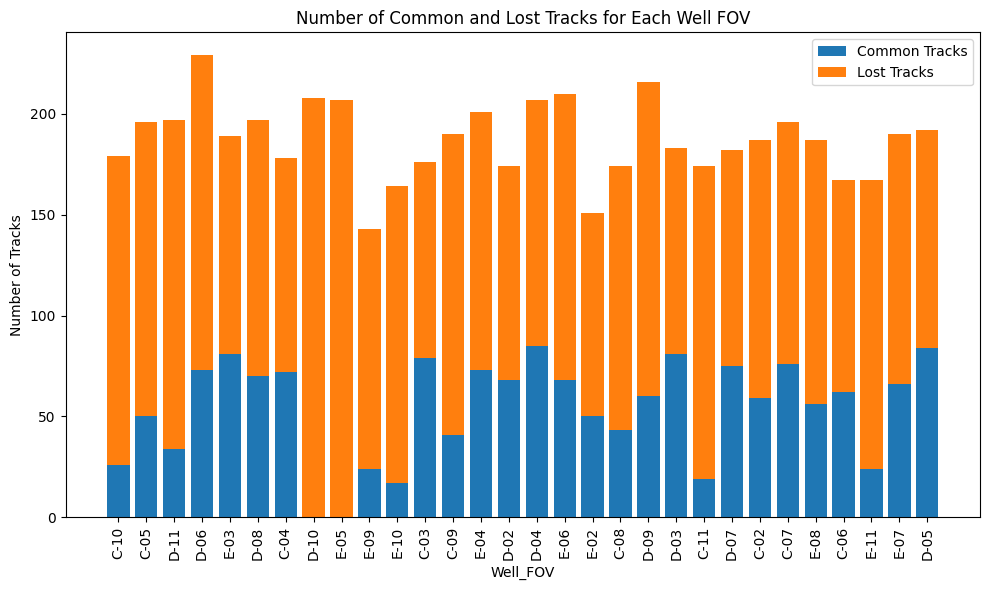

In [5]:
plt.figure(figsize=(10, 6))
# plot a stacked bar chart of number of common tracks and lost tracks for each Well FOV
tracks_stats_df["Well_FOV"] = (
    tracks_stats_df["Metadata_Well"] + "_" + tracks_stats_df["Metadata_FOV"]
)
plt.bar(
    tracks_stats_df["Metadata_Well"],
    tracks_stats_df["number_of_common_tracks"],
    label="Common Tracks",
)
plt.bar(
    tracks_stats_df["Metadata_Well"],
    tracks_stats_df["number_of_lost_tracks"],
    bottom=tracks_stats_df["number_of_common_tracks"],
    label="Lost Tracks",
)
plt.xticks(rotation=90)
plt.xlabel("Well_FOV")
plt.ylabel("Number of Tracks")
plt.title("Number of Common and Lost Tracks for Each Well FOV")
plt.legend()
plt.tight_layout()
pathlib.Path("../figures").mkdir(parents=True, exist_ok=True)
plt.savefig("../figures/common_and_lost_tracks_by_well_fov.png")
plt.show()

In [6]:
# retain only the shared tracks in the combined_df and the endpoint_df
original_combined_df_shape = combined_df.shape
original_endpoint_df_shape = endpoint_df.shape
filtered_combined_df = combined_df.merge(
    shared_track_ids_df,
    on=["Metadata_Well", "Metadata_FOV", "Metadata_track_id"],
    how="inner",
)
filtered_endpoint_df = endpoint_df.merge(
    shared_track_ids_df,
    on=["Metadata_Well", "Metadata_FOV", "Metadata_track_id"],
    how="inner",
)
print(f"Original combined_df shape: {original_combined_df_shape}")
print(f"Original endpoint_df shape: {original_endpoint_df_shape}")
print(f"Filtered combined_df shape: {filtered_combined_df.shape}")
print(f"Filtered endpoint_df shape: {filtered_endpoint_df.shape}")

Original combined_df shape: (188065, 3874)
Original endpoint_df shape: (17048, 1216)
Filtered combined_df shape: (80956, 3874)
Filtered endpoint_df shape: (16140, 1216)


In [7]:
filtered_combined_df

,Metadata_plate,Metadata_Well,Metadata_number_of_singlecells,Metadata_compound,Metadata_dose,Metadata_control,Metadata_ImageNumber,Metadata_FOV,Metadata_Time,Metadata_Cells_Number_Object_Number,...,channel_DNA_cls_feature_91_scDINO,channel_DNA_cls_feature_92_scDINO,channel_DNA_cls_feature_93_scDINO,channel_DNA_cls_feature_94_scDINO,channel_DNA_cls_feature_95_scDINO,channel_DNA_cls_feature_96_scDINO,channel_DNA_cls_feature_97_scDINO,channel_DNA_cls_feature_98_scDINO,channel_DNA_cls_feature_99_scDINO,channel_DNA_cls_feature_9_scDINO
0,1,C-10,156,Staurosporine,78.13,test,1,0003,0.0,10,...,-0.413004,0.982228,1.487644,0.183418,-0.464693,-0.696133,1.038610,0.218406,-0.063818,-1.270270
1,1,C-10,156,Staurosporine,78.13,test,1,0003,0.0,11,...,-1.030118,-1.324591,-0.858296,1.053740,-1.105719,-0.494646,-0.851002,0.691902,0.559527,0.201144
2,1,C-10,156,Staurosporine,78.13,test,1,0003,0.0,15,...,-0.181102,1.147637,-1.812998,0.598982,0.284866,-0.493472,-0.647101,-0.414834,0.976230,0.073403
3,1,C-10,156,Staurosporine,78.13,test,1,0003,0.0,23,...,-0.336290,-0.587934,0.353555,-0.490037,0.308711,0.985845,-0.096368,0.243567,-0.660680,1.230109
4,1,C-10,156,Staurosporine,78.13,test,1,0003,0.0,27,...,1.308821,0.695029,-0.437855,0.556869,-0.101766,-0.059873,-1.425312,-0.006448,-0.115823,-0.158556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80951,1,E-05,180,Staurosporine,2.44,test,8,0002,7.0,159,...,0.646622,1.121644,-0.811909,-1.327102,-0.783085,-1.004680,-0.245501,-0.145951,-1.134301,0.699870
80952,1,E-05,180,Staurosporine,2.44,test,8,0002,7.0,162,...,0.057804,0.728618,1.392768,-0.377898,-1.820884,0.851235,1.557628,-0.382634,-0.426546,-0.622799
80953,1,E-05,180,Staurosporine,2.44,test,8,0002,7.0,165,...,0.167112,0.578380,-0.019191,0.766423,-0.992332,0.534075,1.988510,0.294360,-0.970418,1.167557
80954,1,E-05,180,Staurosporine,2.44,test,8,0002,7.0,166,...,-0.036580,0.144662,0.706286,0.762470,-0.886924,0.840804,0.995013,-0.526741,-0.719939,-1.641829


In [8]:
# save the filtered dataframes
filtered_combined_df.to_parquet(filtered_normalized_path)
filtered_endpoint_df.to_parquet(filtered_endpoint_path)